In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
# Clean TotalCharges column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

In [ ]:
# Churn rate overall
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(f"Overall Churn Rate: {churn_rate['Yes']:.1f}%")


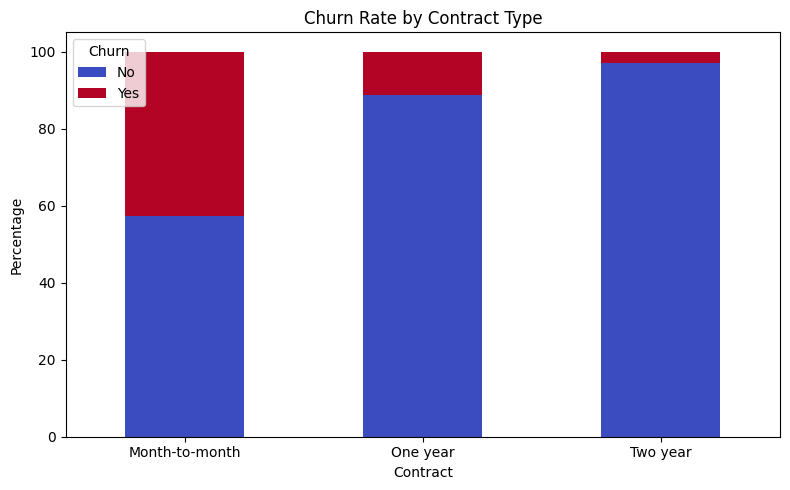

In [ ]:
# Churn by Contract Type
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=True, figsize=(8,5), colormap='coolwarm')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('contract_churn.png')
plt.show()

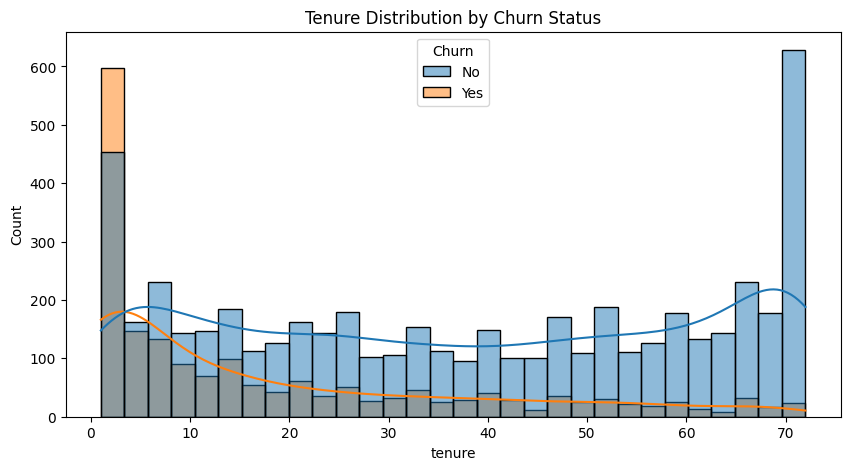

In [ ]:
# Tenure distribution for churned vs non-churned
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, bins=30)
plt.title('Tenure Distribution by Churn Status')
plt.savefig('tenure_churn.png')
plt.show()

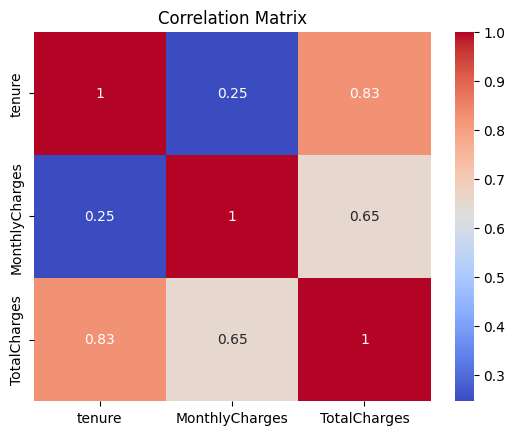

In [ ]:

# Correlation matrix (numeric columns)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig('correlation.png')
plt.show()